# Exploratory Data Analysis: Pediatric Chest X-Ray Pneumonia

Dataset source: Kermany et al. (2018), Guangzhou Women & Children's Medical Center.
Available on Kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

This notebook explores the dataset before any modelling. The goals are to confirm data integrity, surface class imbalance, understand image characteristics that drive preprocessing decisions, and look at sample radiographs from each class.

Outputs (figures in `reports/figures/`) feed both the modelling notebooks and the Streamlit Performance page.

## 1. Setup and imports

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "chest_xray"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir exists:", DATA_DIR.exists())
print("Figures dir:", FIG_DIR)

Project root: D:\ZE5 PORTOFOLIO DS\Medical diagnosis with deep lerning
Data dir exists: True
Figures dir: D:\ZE5 PORTOFOLIO DS\Medical diagnosis with deep lerning\reports\figures


## 2. Build a manifest of every image

We walk the three split folders and parse three pieces of metadata for each file:
- `split`: train / val / test
- `label`: NORMAL or PNEUMONIA
- `subtype`: parsed from filename. PNEUMONIA images encode the cause as `*_bacteria_*.jpeg` or `*_virus_*.jpeg`. NORMAL images are labelled `normal`.

Subtype is not used by the binary classifier but it is interesting as an EDA insight and possible future extension to multi-class.

In [2]:
def parse_subtype(filename: str, label: str) -> str:
    if label == "NORMAL":
        return "normal"
    name = filename.lower()
    if "bacteria" in name:
        return "bacteria"
    if "virus" in name:
        return "virus"
    return "unknown"

rows = []
for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        folder = DATA_DIR / split / label
        if not folder.exists():
            continue
        for fp in folder.glob("*.jpeg"):
            rows.append({
                "filepath": str(fp),
                "filename": fp.name,
                "split": split,
                "label": label,
                "subtype": parse_subtype(fp.name, label),
            })

df = pd.DataFrame(rows)
print(f"Total images: {len(df):,}")
df.head()

Total images: 5,856


,filepath,filename,split,label,subtype
0,D:\ZE5 PORTOFOLIO DS\Medical diagnosis with de...,IM-0115-0001.jpeg,train,NORMAL,normal
1,D:\ZE5 PORTOFOLIO DS\Medical diagnosis with de...,IM-0117-0001.jpeg,train,NORMAL,normal
2,D:\ZE5 PORTOFOLIO DS\Medical diagnosis with de...,IM-0119-0001.jpeg,train,NORMAL,normal
3,D:\ZE5 PORTOFOLIO DS\Medical diagnosis with de...,IM-0122-0001.jpeg,train,NORMAL,normal
4,D:\ZE5 PORTOFOLIO DS\Medical diagnosis with de...,IM-0125-0001.jpeg,train,NORMAL,normal


## 3. Class distribution per split

First check: how many images are in each (split, label) combination.

In [3]:
counts = df.groupby(["split", "label"]).size().unstack(fill_value=0)
counts = counts.reindex(["train", "val", "test"])
counts["total"] = counts.sum(axis=1)
counts["imbalance_ratio"] = (counts["PNEUMONIA"] / counts["NORMAL"]).round(2)
counts

label,NORMAL,PNEUMONIA,total,imbalance_ratio
split,,,,
train,1341,3875,5216,2.89
val,8,8,16,1.00
test,234,390,624,1.67


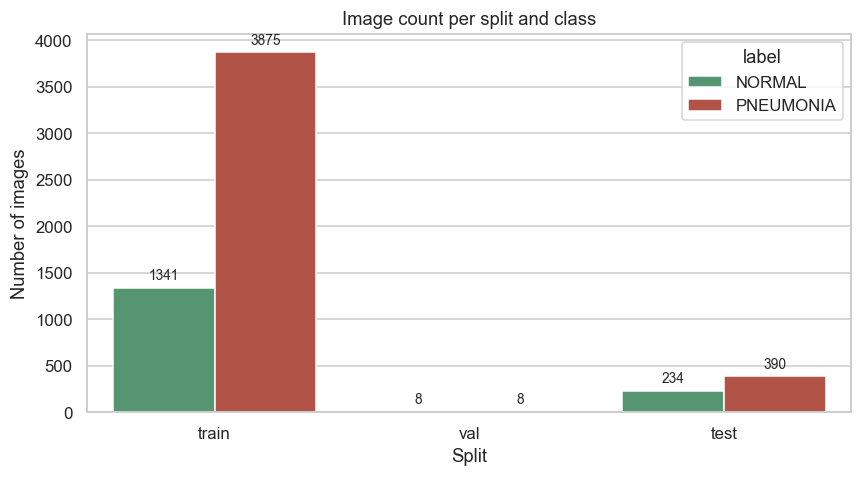

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = counts[["NORMAL", "PNEUMONIA"]].reset_index().melt(
    id_vars="split", var_name="label", value_name="count"
)
sns.barplot(data=plot_df, x="split", y="count", hue="label", ax=ax,
            palette={"NORMAL": "#4C9F70", "PNEUMONIA": "#C44536"})
ax.set_title("Image count per split and class")
ax.set_ylabel("Number of images")
ax.set_xlabel("Split")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

**Observation.** PNEUMONIA dominates at roughly 2.9 to 1 in the train split. The validation set has only 16 images and is not statistically reliable; the preprocessing notebook will resample a larger validation set from train. The class imbalance will be addressed during training using class weights so that the loss function does not get biased toward the majority class.

## 4. Pneumonia subtype distribution

PNEUMONIA labels include both bacterial and viral cases. The classifier treats them as one class, but it is worth knowing the breakdown.

In [5]:
sub_counts = df.groupby(["split", "subtype"]).size().unstack(fill_value=0)
sub_counts = sub_counts.reindex(["train", "val", "test"])
sub_counts

subtype,bacteria,normal,virus
split,,,
train,2530,1341,1345
val,8,8,0
test,242,234,148


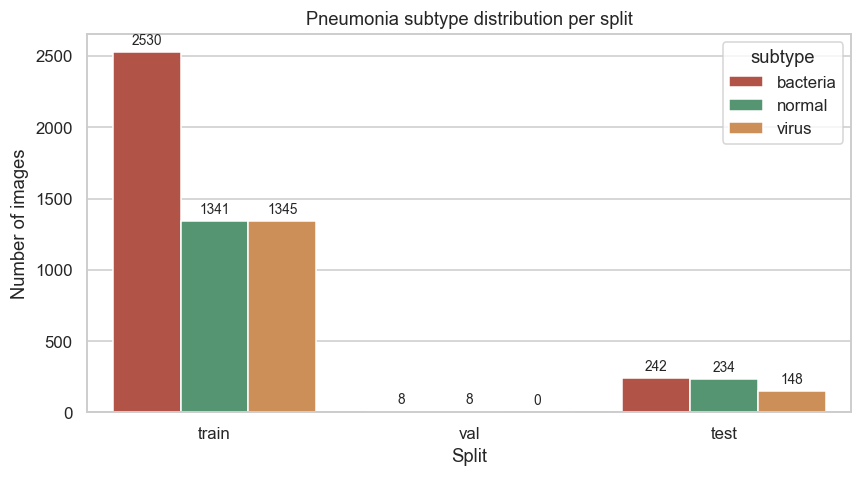

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sub_plot = sub_counts.reset_index().melt(
    id_vars="split", var_name="subtype", value_name="count"
)
sns.barplot(data=sub_plot, x="split", y="count", hue="subtype", ax=ax,
            palette={"normal": "#4C9F70", "bacteria": "#C44536", "virus": "#E08E45"})
ax.set_title("Pneumonia subtype distribution per split")
ax.set_ylabel("Number of images")
ax.set_xlabel("Split")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "subtype_distribution.png", bbox_inches="tight")
plt.show()

**Observation.** Within PNEUMONIA, bacterial cases outnumber viral by roughly 1.9 to 1 in train. A future multi-class extension (Normal vs Bacterial vs Viral) is a natural next step but is out of scope for this binary screening task.

## 5. Image dimensions

We need to resize every image to a fixed size before feeding the model. Looking at the existing dimensions tells us how aggressive that resize will be and whether aspect ratios vary widely.

In [7]:
sample_for_dims = df.sample(n=min(800, len(df)), random_state=42)

widths, heights = [], []
for fp in sample_for_dims["filepath"]:
    with Image.open(fp) as img:
        widths.append(img.width)
        heights.append(img.height)

dim_df = sample_for_dims.assign(width=widths, height=heights)
dim_df[["width", "height"]].describe().round(0)

,width,height
count,800.0,800.0
mean,1341.0,990.0
std,354.0,382.0
min,437.0,132.0
25%,1068.0,696.0
50%,1310.0,920.0
75%,1576.0,1217.0
max,2746.0,2625.0


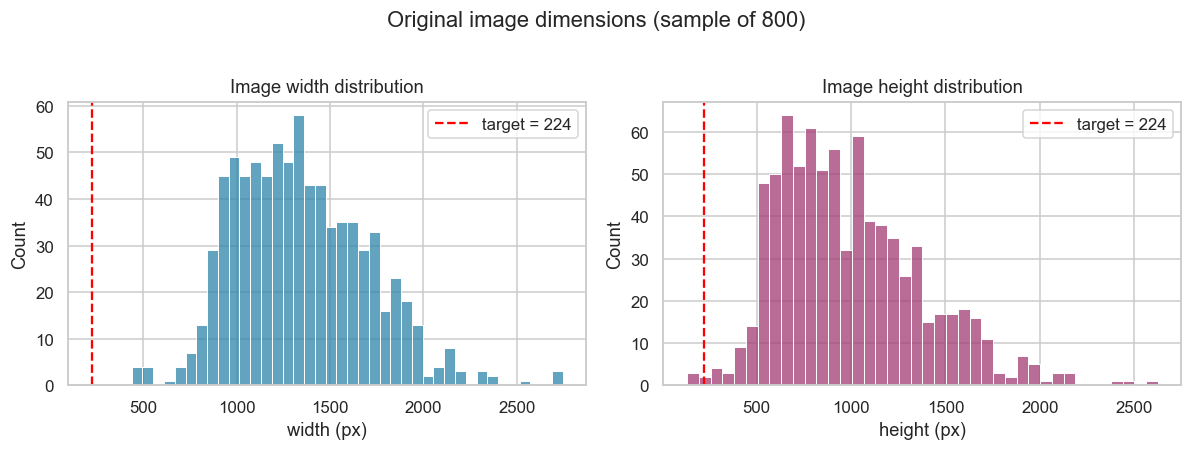

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(dim_df["width"], bins=40, ax=axes[0], color="#2E86AB")
axes[0].axvline(224, color="red", linestyle="--", label="target = 224")
axes[0].set_title("Image width distribution")
axes[0].set_xlabel("width (px)")
axes[0].legend()

sns.histplot(dim_df["height"], bins=40, ax=axes[1], color="#A23B72")
axes[1].axvline(224, color="red", linestyle="--", label="target = 224")
axes[1].set_title("Image height distribution")
axes[1].set_xlabel("height (px)")
axes[1].legend()

fig.suptitle("Original image dimensions (sample of 800)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "image_dimensions.png", bbox_inches="tight")
plt.show()

**Observation.** Image sizes vary considerably (most are above 1000 px on the long edge). Resizing everything to 224x224 sacrifices fine detail but matches the pretrained DenseNet121 input shape and is the standard for transfer learning on ImageNet-derived backbones.

## 6. Mean pixel intensity per class

If the two classes have systematically different exposure or contrast, a model could pick that up as a shortcut rather than learning real anatomy. This is a quick sanity check.

In [9]:
intensity_sample = df.groupby("label", group_keys=False).apply(
    lambda g: g.sample(n=min(300, len(g)), random_state=42)
)

means = []
for fp, label in zip(intensity_sample["filepath"], intensity_sample["label"]):
    with Image.open(fp) as img:
        arr = np.asarray(img.convert("L"), dtype=np.float32)
        means.append({"label": label, "mean_intensity": arr.mean()})

intensity_df = pd.DataFrame(means)
intensity_df.groupby("label")["mean_intensity"].agg(["mean", "std", "min", "max"]).round(1)

C:\Users\rusli\AppData\Local\Temp\ipykernel_13364\320330869.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  intensity_sample = df.groupby("label", group_keys=False).apply(


,mean,std,min,max
label,,,,
NORMAL,123.900002,14.0,80.099998,164.000000
PNEUMONIA,123.199997,18.4,67.099998,180.699997


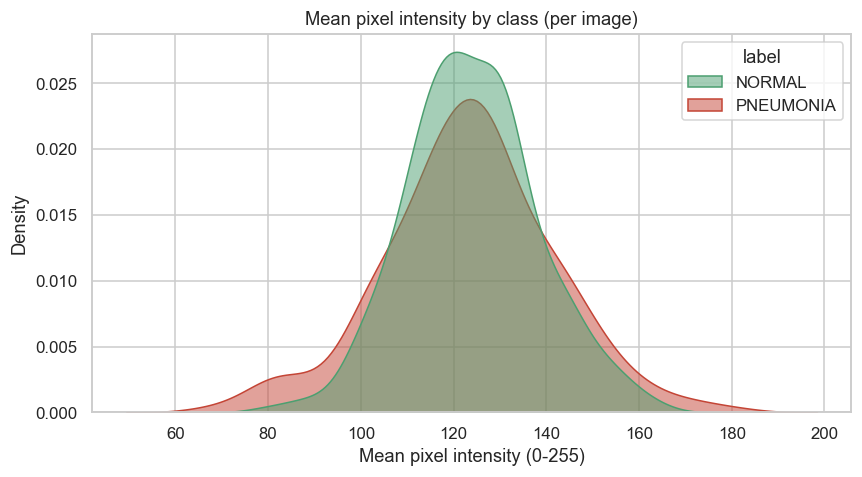

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=intensity_df, x="mean_intensity", hue="label", fill=True,
            common_norm=False, alpha=0.5, ax=ax,
            palette={"NORMAL": "#4C9F70", "PNEUMONIA": "#C44536"})
ax.set_title("Mean pixel intensity by class (per image)")
ax.set_xlabel("Mean pixel intensity (0-255)")
fig.tight_layout()
fig.savefig(FIG_DIR / "intensity_distribution.png", bbox_inches="tight")
plt.show()

**Observation.** The two distributions overlap heavily, with PNEUMONIA images skewing slightly brighter on average. The overlap is large enough that intensity alone cannot separate the classes, which is good. The model will need to use spatial features.

## 7. Sample images by class and subtype

Look at the data with our own eyes. Bacterial pneumonia tends to show focal lobar consolidation; viral pneumonia tends to show a more diffuse interstitial pattern; normal lungs show clear lung fields. These are the patterns the model will need to learn.

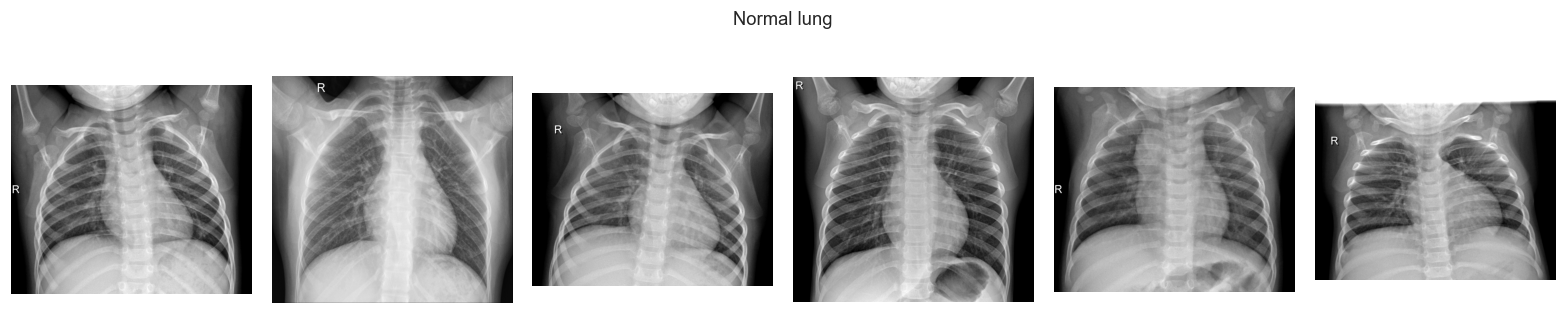

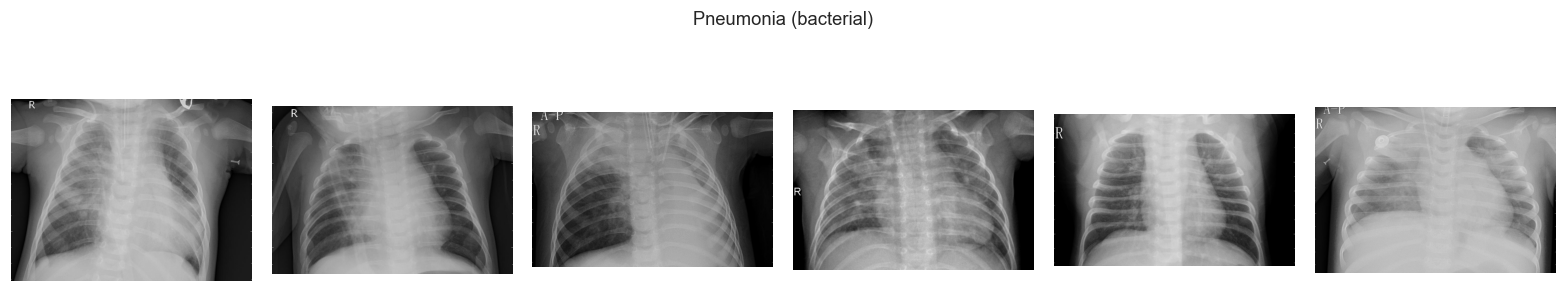

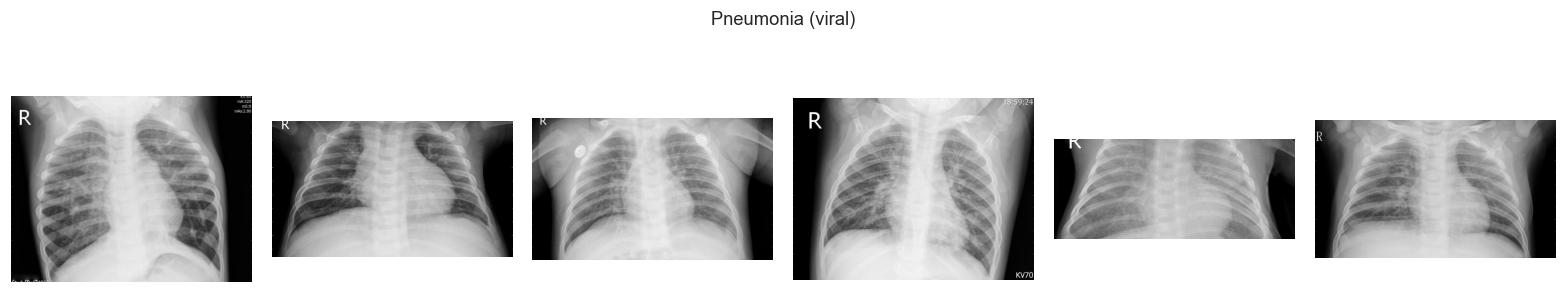

In [11]:
def show_samples(category_df, title, n=6):
    sample = category_df.sample(n=n, random_state=7)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.4, 2.8))
    for ax, fp in zip(axes, sample["filepath"]):
        with Image.open(fp) as img:
            ax.imshow(img.convert("L"), cmap="gray")
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()
    return fig

train_df = df[df["split"] == "train"]
fig_n = show_samples(train_df[train_df["subtype"] == "normal"], "Normal lung")
fig_n.savefig(FIG_DIR / "samples_normal.png", bbox_inches="tight")
fig_b = show_samples(train_df[train_df["subtype"] == "bacteria"], "Pneumonia (bacterial)")
fig_b.savefig(FIG_DIR / "samples_bacteria.png", bbox_inches="tight")
fig_v = show_samples(train_df[train_df["subtype"] == "virus"], "Pneumonia (viral)")
fig_v.savefig(FIG_DIR / "samples_virus.png", bbox_inches="tight")
plt.show()

## 8. Persist the manifest

Save the dataframe so other notebooks do not have to re-walk the file tree.

In [12]:
manifest_path = PROJECT_ROOT / "reports" / "image_manifest.csv"
df.to_csv(manifest_path, index=False)

summary = {
    "total_images": int(len(df)),
    "per_split": {s: int(c) for s, c in df["split"].value_counts().items()},
    "per_label": {l: int(c) for l, c in df["label"].value_counts().items()},
    "per_subtype": {s: int(c) for s, c in df["subtype"].value_counts().items()},
    "train_imbalance_ratio": round(
        len(df[(df.split == "train") & (df.label == "PNEUMONIA")]) /
        max(1, len(df[(df.split == "train") & (df.label == "NORMAL")])), 2
    ),
}
(PROJECT_ROOT / "reports" / "eda_summary.json").write_text(json.dumps(summary, indent=2))
print("Manifest written to:", manifest_path)
summary

Manifest written to: D:\ZE5 PORTOFOLIO DS\Medical diagnosis with deep lerning\reports\image_manifest.csv


{'total_images': 5856,
 'per_split': {'train': 5216, 'test': 624, 'val': 16},
 'per_label': {'PNEUMONIA': 4273, 'NORMAL': 1583},
 'per_subtype': {'bacteria': 2780, 'normal': 1583, 'virus': 1493},
 'train_imbalance_ratio': 2.89}

## Summary

- 5,856 images across 3 splits, 2 classes (NORMAL, PNEUMONIA), with a bacterial / viral subdivision inside PNEUMONIA.
- Train is imbalanced (PNEUMONIA roughly 2.9x NORMAL). Will be handled with class weights.
- The original validation set is too small (16 images). The preprocessing notebook will build a larger stratified validation set from train.
- Image dimensions vary widely; resize to 224x224 fits the DenseNet121 input.
- Mean pixel intensity overlaps heavily between classes, so the model cannot rely on global brightness as a shortcut.

Next: `02_preprocessing.ipynb` builds the `tf.data` pipeline and computes class weights.